# 00 — Diagnóstico y comprensión de datos (Fase 1 / Ruta C)

**Objetivo:** conectarse en vivo al MySQL CDR de Asterisk y al índice del
filesystem de grabaciones para replicar las consultas E1–E6, generar figuras y
exportar las **Tablas 1 y 2** del capítulo académico, cerrando la Fase 1 con
evidencia reproducible.

> Todo corre dentro del contenedor `uisrael_diagnostico`. Las credenciales se
> leen de `.env` (nunca embebidas en el notebook). Acceso al CDR **solo lectura**.

Para exportar a `.ipynb` (entregable del capítulo):
```bash
jupytext --to notebook notebooks/00_diagnostico.py
```

In [1]:
import os
import gzip
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

load_dotenv()  # lee /work/.env montado (o variables del env_file de compose)

OUT_DIR = Path(os.getenv("OUT_DIR", "/work/data/diag"))
FIG_DIR = OUT_DIR / "figuras"
TAB_DIR = OUT_DIR / "tablas"
for d in (OUT_DIR, FIG_DIR, TAB_DIR):
    d.mkdir(parents=True, exist_ok=True)

CDR_TABLE = os.getenv("CDR_TABLE", "cdr")
print("Salidas ->", OUT_DIR)

Salidas -> /work/data/diag


In [2]:
def get_engine():
    """Motor SQLAlchemy de SOLO LECTURA al CDR de Asterisk (latin1 -> UTF-8)."""
    user = os.environ["CDR_USER"]
    pwd = os.environ["CDR_PASSWORD"]
    host = os.environ["CDR_HOST"]
    port = os.getenv("CDR_PORT", "3306")
    db = os.environ["CDR_DB"]
    charset = os.getenv("CDR_CHARSET", "latin1")
    url = f"mysql+pymysql://{user}:{pwd}@{host}:{port}/{db}?charset={charset}"
    return create_engine(url, pool_pre_ping=True)


engine = get_engine()

# Sanidad: ¿conecta y cuántas columnas tiene el CDR?
with engine.connect() as c:
    cols = pd.read_sql(text(f"SHOW COLUMNS FROM {CDR_TABLE}"), c)
print(f"Conexión OK. Columnas en `{CDR_TABLE}`:")
cols

Conexión OK. Columnas en `cdr`:


,Field,Type,Null,Key,Default,Extra
0,calldate,datetime,NO,MUL,0000-00-00 00:00:00,
1,clid,varchar(80),NO,,,
2,src,varchar(80),NO,MUL,,
3,dst,varchar(80),NO,MUL,,
4,dcontext,varchar(80),NO,,,
5,channel,varchar(80),NO,,,
6,dstchannel,varchar(80),NO,,,
7,lastapp,varchar(80),NO,,,
8,lastdata,varchar(80),NO,,,
9,duration,int(11),NO,,0,


## E1 — Volúmenes por año y `disposition`
Confirma el universo real (~24,76 M CDR) y la distribución de resultados.

In [3]:
q_e1 = text(f"""
    SELECT YEAR(calldate) AS anio, disposition, COUNT(*) AS n
    FROM {CDR_TABLE}
    WHERE calldate <> '0000-00-00 00:00:00'
    GROUP BY YEAR(calldate), disposition
    ORDER BY anio, disposition
""")
e1 = pd.read_sql(q_e1, engine)
piv_e1 = e1.pivot_table(index="anio", columns="disposition", values="n",
                        aggfunc="sum", fill_value=0)
piv_e1["TOTAL"] = piv_e1.sum(axis=1)
piv_e1

disposition,ANSWERED,BUSY,FAILED,NO ANSWER,TOTAL
anio,,,,,
2018,723196,27877,21572,453472,1226117
2019,3142736,200670,180379,2270367,5794152
2020,1500807,91854,14694,925740,2533095
2021,1529876,99464,13455,1056735,2699530
2022,1369154,48313,9998,1092204,2519669
2023,1397816,57156,13602,1238230,2706804
2024,1387265,111250,26089,1519740,3044344
2025,1268883,100208,20253,1212950,2602294
2026,553956,73058,3740,458386,1089140


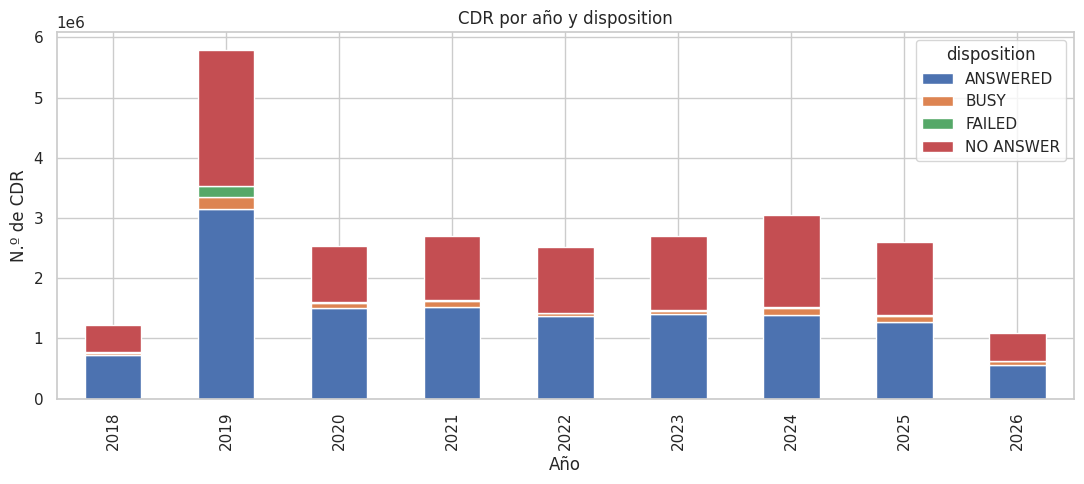

In [4]:
ax = piv_e1.drop(columns="TOTAL").plot(kind="bar", stacked=True, figsize=(11, 5))
ax.set_title("CDR por año y disposition")
ax.set_xlabel("Año"); ax.set_ylabel("N.º de CDR")
plt.tight_layout(); plt.savefig(FIG_DIR / "e1_cdr_por_anio.png", dpi=150); plt.show()

## E2 — Registros corruptos (`calldate = '0000-00-00'`)
Esperado ≈ 2,25 %, coincidentes con `src`/`disposition` vacíos → descartar en Bronce.

In [5]:
q_e2 = text(f"""
    SELECT
      COUNT(*) AS total,
      SUM(calldate = '0000-00-00 00:00:00') AS corruptos,
      SUM(calldate = '0000-00-00 00:00:00' AND (src = '' OR src IS NULL)) AS corr_src_vacio,
      SUM(calldate = '0000-00-00 00:00:00' AND (disposition = '' OR disposition IS NULL)) AS corr_disp_vacio
    FROM {CDR_TABLE}
""")
e2 = pd.read_sql(q_e2, engine)
e2["pct_corruptos"] = 100 * e2["corruptos"] / e2["total"]
e2

,total,corruptos,corr_src_vacio,corr_disp_vacio,pct_corruptos
0,24773167,"558,021.00","558,021.00","558,021.00",2.25


## E3 — Tasa de llenado del IVR (`pregunta1/2/3`)
Esperado < 0,001 % → **descartado** como señal analítica. (Se salta si las columnas no existen.)

In [6]:
col_names = set(cols["Field"].str.lower())
if {"pregunta1", "pregunta2", "pregunta3"} & col_names:
    q_e3 = text(f"""
        SELECT
          COUNT(*) AS total,
          SUM(pregunta1 IS NOT NULL AND pregunta1 <> '') AS p1,
          SUM(pregunta2 IS NOT NULL AND pregunta2 <> '') AS p2,
          SUM(pregunta3 IS NOT NULL AND pregunta3 <> '') AS p3
        FROM {CDR_TABLE}
    """)
    e3 = pd.read_sql(q_e3, engine)
    display(e3)
else:
    print("Sin columnas pregunta1/2/3 en este esquema — nada que evaluar.")

,total,p1,p2,p3
0,24773168,31.00,31.00,2.00


## E4 — Utilización de `urlrecord`
Esperado ≈ 0,13 % → el enlace por reconstrucción del filesystem es el camino PRINCIPAL.

In [7]:
if "urlrecord" in col_names:
    q_e4 = text(f"""
        SELECT COUNT(*) AS total,
               SUM(urlrecord IS NOT NULL AND urlrecord <> '') AS con_url
        FROM {CDR_TABLE}
    """)
    e4 = pd.read_sql(q_e4, engine)
    e4["pct_con_url"] = 100 * e4["con_url"] / e4["total"]
    display(e4)
else:
    print("Sin columna urlrecord en este esquema.")

,total,con_url,pct_con_url
0,24773169,"33,055.00",0.13


## E5 — Contactabilidad, duración/billsec e interanual
Contactabilidad global ≈ 53 %; caída interanual 2020→2024 (efecto TrueCaller);
outliers de `duration` por `hangup` fallido (máx ≈ 86 días).

In [8]:
q_e5_global = text(f"""
    SELECT
      COUNT(*) AS validos,
      SUM(disposition = 'ANSWERED') AS answered,
      AVG(CASE WHEN disposition='ANSWERED' THEN duration END) AS dur_media,
      MAX(CASE WHEN disposition='ANSWERED' THEN duration END) AS dur_max,
      AVG(CASE WHEN disposition='ANSWERED' THEN billsec  END) AS billsec_media
    FROM {CDR_TABLE}
    WHERE calldate <> '0000-00-00 00:00:00'
""")
e5g = pd.read_sql(q_e5_global, engine)
e5g["contactabilidad_pct"] = 100 * e5g["answered"] / e5g["validos"]
e5g

,validos,answered,dur_media,dur_max,billsec_media,contactabilidad_pct
0,24215148,"12,873,689.00",59.90,7441536,52.46,53.16


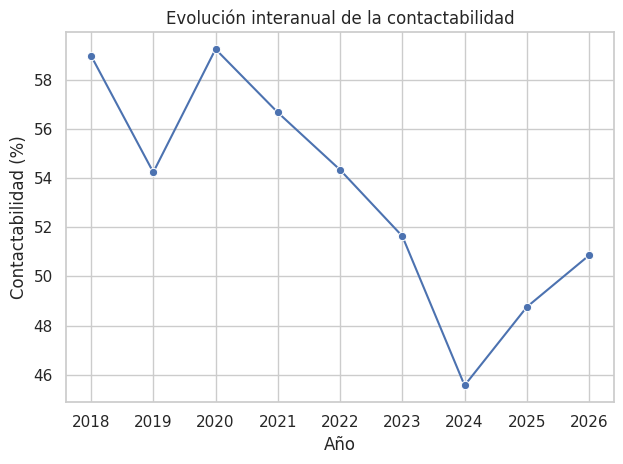

,anio,validos,answered,contactabilidad_pct
0,2018,1226117,"723,196.00",58.98
1,2019,5794152,"3,142,736.00",54.24
2,2020,2533095,"1,500,807.00",59.25
3,2021,2699530,"1,529,876.00",56.67
4,2022,2519669,"1,369,154.00",54.34
5,2023,2706804,"1,397,816.00",51.64
6,2024,3044344,"1,387,265.00",45.57
7,2025,2602294,"1,268,883.00",48.76
8,2026,1089144,"553,956.00",50.86


In [9]:
q_e5_anual = text(f"""
    SELECT YEAR(calldate) AS anio,
           COUNT(*) AS validos,
           SUM(disposition='ANSWERED') AS answered
    FROM {CDR_TABLE}
    WHERE calldate <> '0000-00-00 00:00:00'
    GROUP BY YEAR(calldate) ORDER BY anio
""")
e5a = pd.read_sql(q_e5_anual, engine)
e5a["contactabilidad_pct"] = 100 * e5a["answered"] / e5a["validos"]

ax = sns.lineplot(data=e5a, x="anio", y="contactabilidad_pct", marker="o")
ax.set_title("Evolución interanual de la contactabilidad")
ax.set_xlabel("Año"); ax.set_ylabel("Contactabilidad (%)")
plt.tight_layout(); plt.savefig(FIG_DIR / "e5_contactabilidad_anual.png", dpi=150); plt.show()
e5a

## E6 — Top 20 agentes (`src`), distribución por hora y por día de la semana

In [10]:
q_top = text(f"""
    SELECT src, COUNT(*) AS n
    FROM {CDR_TABLE}
    WHERE calldate <> '0000-00-00 00:00:00'
    GROUP BY src ORDER BY n DESC LIMIT 20
""")
top_src = pd.read_sql(q_top, engine)
top_src

,src,n
0,964256639,762313
1,23815940,753041
2,963150315,631047
3,963166652,630141
4,963161268,630110
5,963161474,629807
6,963155909,629709
7,963155676,629562
8,963155716,629012
9,963161019,625535


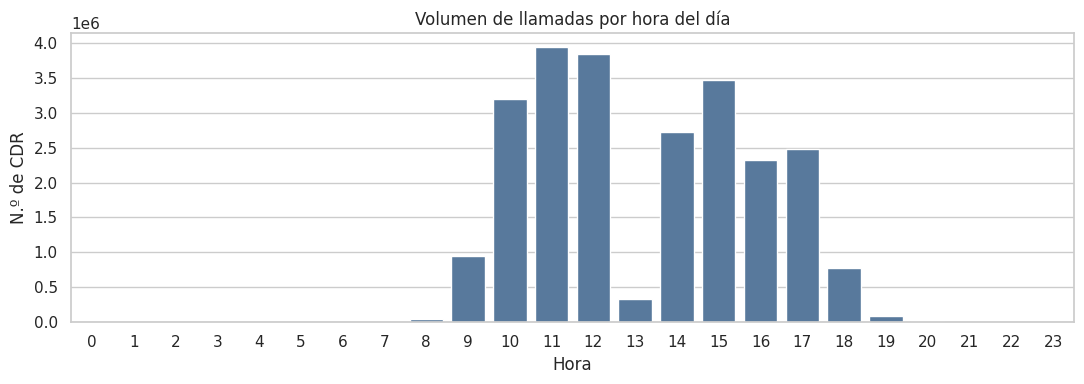

In [11]:
q_hora = text(f"""
    SELECT HOUR(calldate) AS hora,
           COUNT(*) AS n,
           SUM(disposition='ANSWERED') AS answered
    FROM {CDR_TABLE}
    WHERE calldate <> '0000-00-00 00:00:00'
    GROUP BY HOUR(calldate) ORDER BY hora
""")
por_hora = pd.read_sql(q_hora, engine)

fig, ax = plt.subplots(figsize=(11, 4))
sns.barplot(data=por_hora, x="hora", y="n", ax=ax, color="#4C78A8")
ax.set_title("Volumen de llamadas por hora del día")
ax.set_xlabel("Hora"); ax.set_ylabel("N.º de CDR")
plt.tight_layout(); plt.savefig(FIG_DIR / "e6_por_hora.png", dpi=150); plt.show()

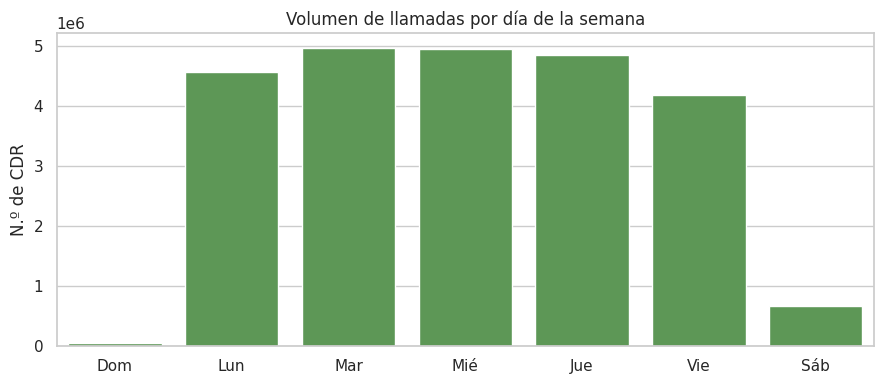

,dow,n,answered,dia
0,1,39071,"19,383.00",Dom
1,2,4557388,"2,443,172.00",Lun
2,3,4968514,"2,637,578.00",Mar
3,4,4943317,"2,636,509.00",Mié
4,5,4855050,"2,563,421.00",Jue
5,6,4183770,"2,223,740.00",Vie
6,7,668041,"349,888.00",Sáb


In [12]:
q_dow = text(f"""
    SELECT DAYOFWEEK(calldate) AS dow,
           COUNT(*) AS n,
           SUM(disposition='ANSWERED') AS answered
    FROM {CDR_TABLE}
    WHERE calldate <> '0000-00-00 00:00:00'
    GROUP BY DAYOFWEEK(calldate) ORDER BY dow
""")
por_dia = pd.read_sql(q_dow, engine)
dias = {1: "Dom", 2: "Lun", 3: "Mar", 4: "Mié", 5: "Jue", 6: "Vie", 7: "Sáb"}
por_dia["dia"] = por_dia["dow"].map(dias)

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=por_dia, x="dia", y="n", ax=ax, color="#54A24B")
ax.set_title("Volumen de llamadas por día de la semana")
ax.set_xlabel(""); ax.set_ylabel("N.º de CDR")
plt.tight_layout(); plt.savefig(FIG_DIR / "e6_por_dia.png", dpi=150); plt.show()
por_dia

## Audio — Caracterización del filesystem de grabaciones

Requiere `data/diag/audio_index.tsv.gz` (generado por `scripts/diagnostico_audio.sh`
en el servidor Asterisk y descargado con `scp`). Aquí lo parseamos: tamaño total,
`.mp3` vs `.wav`, archivos "regados" (fuera de `{ext}/OUT/`) y años.

In [13]:
AUDIO_INDEX = Path(os.getenv("AUDIO_INDEX", "/work/data/diag/audio_index.tsv.gz"))

if AUDIO_INDEX.exists():
    audio = pd.read_csv(AUDIO_INDEX, sep="\t", names=["path", "bytes", "mtime"],
                        header=None)
    audio["ext"] = audio["path"].str.extract(r"\.(mp3|wav)$", expand=False).str.lower()
    audio["mtime"] = pd.to_datetime(audio["mtime"], unit="s", errors="coerce")
    audio["fname"] = audio["path"].str.rsplit("/", n=1).str[-1]
    # Patrón esperado: {YYYYMMDDHHmmss}-{ext}-{seq}
    parsed = audio["fname"].str.extract(r"(?P<ts>\d{14})-(?P<agente>\d+)-(?P<dst>\w+)")
    audio = pd.concat([audio, parsed], axis=1)
    audio["ts_parse"] = pd.to_datetime(audio["ts"], format="%Y%m%d%H%M%S", errors="coerce")
    audio["anio"] = audio["ts_parse"].dt.year.fillna(audio["mtime"].dt.year)
    audio["regado"] = ~audio["path"].str.contains("/OUT/", case=False, regex=False)

    resumen_audio = pd.DataFrame({
        "métrica": [
            "Archivos totales", "  .mp3", "  .wav (sin convertir)",
            "Tamaño total (GB)", "Regados (fuera de {ext}/OUT/)",
            "Nombre no parseable",
        ],
        "valor": [
            len(audio),
            int((audio["ext"] == "mp3").sum()),
            int((audio["ext"] == "wav").sum()),
            round(audio["bytes"].sum() / 1024**3, 2),
            int(audio["regado"].sum()),
            int(audio["ts_parse"].isna().sum()),
        ],
    })
    display(resumen_audio)

    por_anio_audio = audio.groupby("anio").size().rename("archivos").reset_index()
    display(por_anio_audio)
    resumen_audio.to_csv(TAB_DIR / "tabla1b_audio_resumen.csv", index=False)
else:
    print(f"Falta {AUDIO_INDEX}. Corre scripts/diagnostico_audio.sh en el servidor")
    print("y descárgalo:  scp USER@IP_ASTERISK:/tmp/diag/audio_index.tsv.gz ./data/diag/")
    audio = None

Falta /work/data/diag/audio_index.tsv.gz. Corre scripts/diagnostico_audio.sh en el servidor
y descárgalo:  scp USER@IP_ASTERISK:/tmp/diag/audio_index.tsv.gz ./data/diag/


## Cruce CDR ↔ grabación — tasa de emparejamiento

Umbral de gobernanza: **cobertura ≥ 95 %** en la muestra analítica y
**precisión de linkage ≥ 0,98** (verificación a oído aparte).
Parametrizado por rango de fechas para mantenerlo tratable en la laptop.

In [14]:
FECHA_DESDE = "2024-01-01"
FECHA_HASTA = "2024-12-31"

if audio is not None:
    q_muestra = text(f"""
        SELECT uniqueid, calldate, src, dst, duration, billsec, disposition
        FROM {CDR_TABLE}
        WHERE calldate BETWEEN :d AND :h
          AND disposition = 'ANSWERED'
          AND billsec BETWEEN 10 AND 3600
    """)
    cdr = pd.read_sql(q_muestra, engine, params={"d": FECHA_DESDE, "h": FECHA_HASTA})
    cdr["key"] = (pd.to_datetime(cdr["calldate"]).dt.strftime("%Y%m%d%H%M%S")
                  + "-" + cdr["src"].astype(str))

    aud = audio.dropna(subset=["ts", "agente"]).copy()
    aud["key"] = aud["ts"] + "-" + aud["agente"].astype(str)

    matched = cdr["key"].isin(set(aud["key"]))
    cobertura = 100 * matched.mean() if len(cdr) else float("nan")
    print(f"Muestra CDR {FECHA_DESDE}..{FECHA_HASTA} (ANSWERED, billsec 10–3600): {len(cdr):,}")
    print(f"Emparejados por (timestamp exacto + agente): {matched.sum():,}  "
          f"=> cobertura {cobertura:.2f} %")
    print("Nota: emparejar por segundo exacto es estricto; si la cobertura es baja,")
    print("probar tolerancia ±1–2 s o join por minuto — se ajusta aquí.")
else:
    print("Sin índice de audio: no se puede calcular el cruce todavía.")

Sin índice de audio: no se puede calcular el cruce todavía.


## Exportación de Tablas 1 y 2 (capítulo académico)

In [15]:
with pd.ExcelWriter(TAB_DIR / "tablas_diagnostico.xlsx") as xl:
    piv_e1.to_excel(xl, sheet_name="E1_por_anio")
    e2.to_excel(xl, sheet_name="E2_corruptos", index=False)
    e5g.to_excel(xl, sheet_name="E5_global", index=False)
    e5a.to_excel(xl, sheet_name="E5_anual", index=False)
    top_src.to_excel(xl, sheet_name="E6_top_agentes", index=False)
    por_hora.to_excel(xl, sheet_name="E6_por_hora", index=False)
    por_dia.to_excel(xl, sheet_name="E6_por_dia", index=False)
print("Tablas exportadas a", TAB_DIR / "tablas_diagnostico.xlsx")

Tablas exportadas a /work/data/diag/tablas/tablas_diagnostico.xlsx
